# Electricity Theft Detection

Model Evaluation

In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("dataset.csv")
df.head()

,FLAG,mean_consumption,std_consumption,cv,num_zeros,trend_slope,sudden_drop_count,min_consumption,max_consumption,median_consumption,num_below_mean,skewness,iqr,max_drop_pct
0,1.0,13.898342,6.683785,0.480905,0,-0.000364,46,2.46,46.49,13.898342,811,1.513367,5.095842,0.926731
1,1.0,0.000000,0.000000,0.000000,1034,0.000000,0,0.00,0.00,0.000000,0,0.000000,0.000000,0.000000
2,1.0,9.921390,3.409611,0.343663,41,-0.000358,15,0.00,32.81,9.921390,160,1.976875,0.000000,1.000000
3,1.0,14.612055,7.712976,0.527850,0,0.012225,56,0.40,52.76,14.612055,266,0.984226,0.399555,0.992418
4,1.0,8.249738,5.930837,0.718912,0,0.010040,51,0.85,43.43,6.280000,694,2.597712,5.197500,0.750733


In [2]:
drop_cols = [
    'median_consumption',
    'max_consumption',
    'trend_slope',
    'num_zeros'
]

df = df.drop(columns=drop_cols)


In [3]:
df.head()

,FLAG,mean_consumption,std_consumption,cv,sudden_drop_count,min_consumption,num_below_mean,skewness,iqr,max_drop_pct
0,1.0,13.898342,6.683785,0.480905,46,2.46,811,1.513367,5.095842,0.926731
1,1.0,0.000000,0.000000,0.000000,0,0.00,0,0.000000,0.000000,0.000000
2,1.0,9.921390,3.409611,0.343663,15,0.00,160,1.976875,0.000000,1.000000
3,1.0,14.612055,7.712976,0.527850,56,0.40,266,0.984226,0.399555,0.992418
4,1.0,8.249738,5.930837,0.718912,51,0.85,694,2.597712,5.197500,0.750733


In [4]:
df.shape

(77510, 10)

In [5]:
df = df.rename(columns={'FLAG': 'target'})


XGBoost

In [6]:
from sklearn.model_selection import train_test_split
X = df.drop('target', axis=1)
y = df['target']


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [8]:
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier


In [9]:
from sklearn import set_config
set_config(display='text')

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [10]:
from sklearn.metrics import accuracy_score
y_pred = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9545


In [11]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

         0.0       0.92      1.00      0.96      7751
         1.0       1.00      0.91      0.95      7751

    accuracy                           0.95     15502
   macro avg       0.96      0.95      0.95     15502
weighted avg       0.96      0.95      0.95     15502



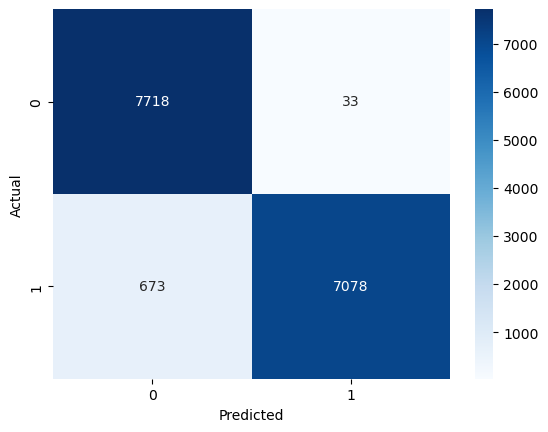

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


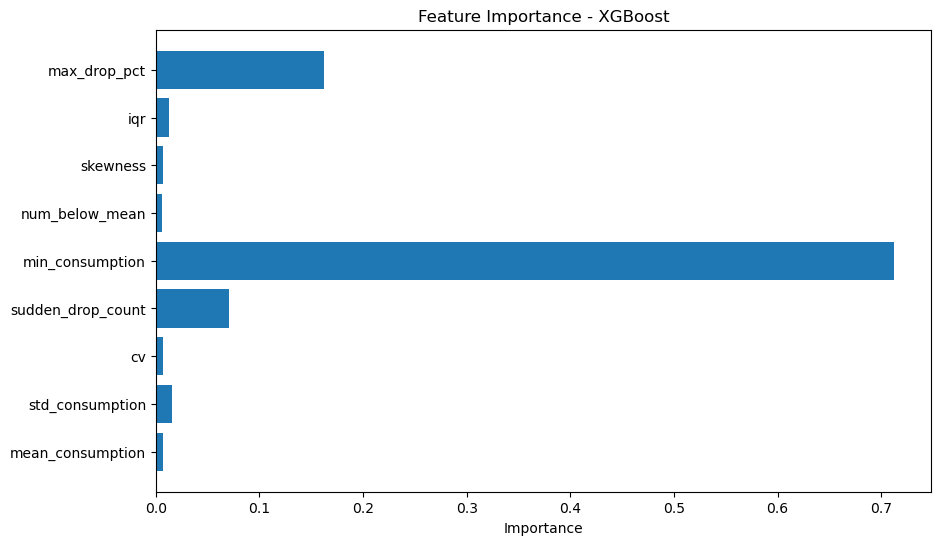

In [13]:
import matplotlib.pyplot as plt

importances = xgb_model.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance - XGBoost")
plt.show()


XGBoost AUC: 0.9761494893946289


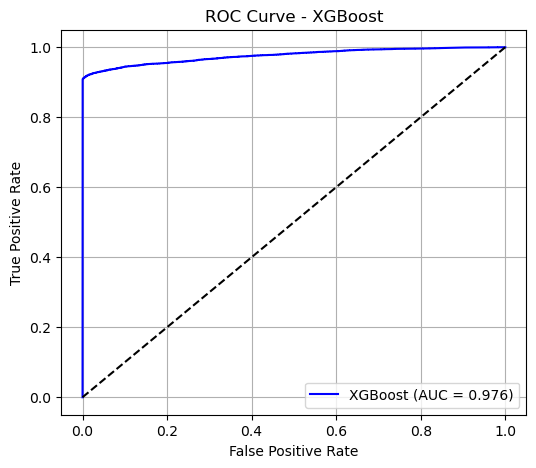

In [14]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Calculate AUC
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print("XGBoost AUC:", auc_xgb)

# ROC Curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(6,5))
plt.plot(fpr_xgb, tpr_xgb, color='blue', label=f'XGBoost (AUC = {auc_xgb:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.grid()
plt.show()


LightGBM

In [15]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report

In [16]:
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    min_child_samples=20,
    random_state=42,
    verbose=-1
)


In [17]:
lgbm_model.fit(X_train, y_train)

LGBMClassifier(learning_rate=0.05, max_depth=8, n_estimators=300,
               random_state=42, verbose=-1)

In [18]:
from sklearn.metrics import accuracy_score

y_pred = lgbm_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.9544574893562121


In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

         0.0       0.92      1.00      0.96      7751
         1.0       1.00      0.91      0.95      7751

    accuracy                           0.95     15502
   macro avg       0.96      0.95      0.95     15502
weighted avg       0.96      0.95      0.95     15502



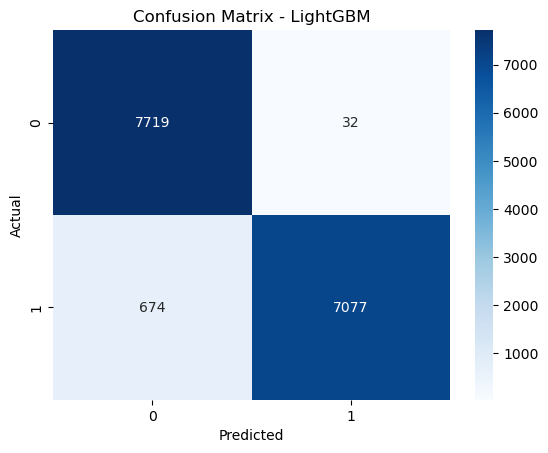

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - LightGBM")
plt.show()


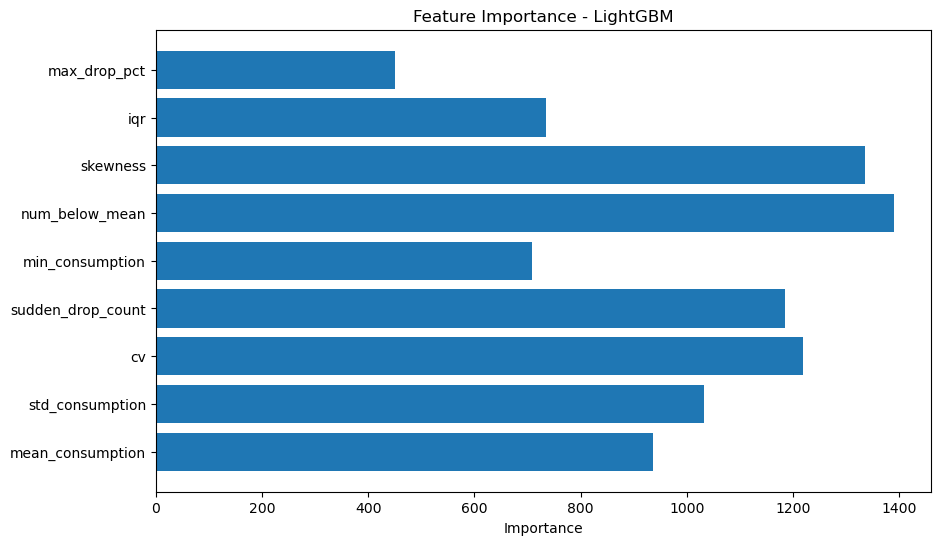

In [21]:
import matplotlib.pyplot as plt

importances = lgbm_model.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance - LightGBM")
plt.show()


LightGBM AUC: 0.9766254206760308


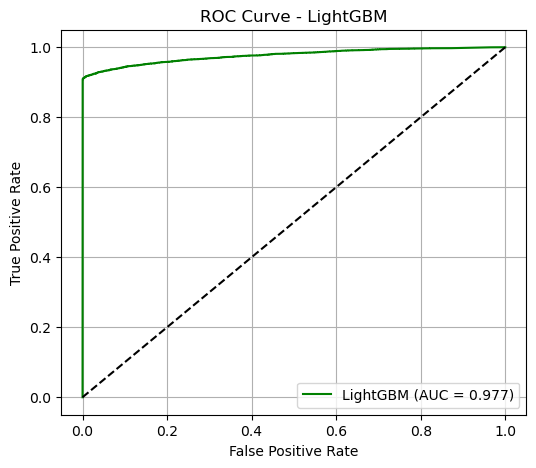

In [22]:
# Predict probabilities
y_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

# Calculate AUC
auc_lgbm = roc_auc_score(y_test, y_prob_lgbm)
print("LightGBM AUC:", auc_lgbm)

# ROC Curve
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_prob_lgbm)

plt.figure(figsize=(6,5))
plt.plot(fpr_lgbm, tpr_lgbm, color='green', label=f'LightGBM (AUC = {auc_lgbm:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LightGBM")
plt.legend()
plt.grid()
plt.show()


To improve the model Performance we are doing Hyper parameter tuning 

XGBoost

In [23]:
# If not installed
# pip install xgboost

import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.datasets import make_classification


In [24]:
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)


In [25]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}


In [26]:
import xgboost
import sklearn

print("XGBoost version:", xgboost.__version__)
print("Scikit-learn version:", sklearn.__version__)


XGBoost version: 2.1.1
Scikit-learn version: 1.4.2


In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importanc...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                

In [28]:
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validated ROC-AUC:", grid_search.best_score_)


Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Best Cross-Validated ROC-AUC: 0.9765842927811603


In [29]:
best_xgbmodel = grid_search.best_estimator_

y_pred = best_xgbmodel.predict(X_test)
y_prob = best_xgbmodel.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Test Accuracy:", accuracy)
print("Test ROC-AUC:", roc_auc)


Test Accuracy: 0.9545865049671011
Test ROC-AUC: 0.9772512321107355


In [30]:
from sklearn.metrics import classification_report

# Predictions
y_pred_xgb = best_xgbmodel.predict(X_test)

# Classification Report
print("📊 XGBoost Classification Report:\n")
print(classification_report(y_test, y_pred_xgb))


📊 XGBoost Classification Report:

              precision    recall  f1-score   support

         0.0       0.92      1.00      0.96      7751
         1.0       1.00      0.91      0.95      7751

    accuracy                           0.95     15502
   macro avg       0.96      0.95      0.95     15502
weighted avg       0.96      0.95      0.95     15502



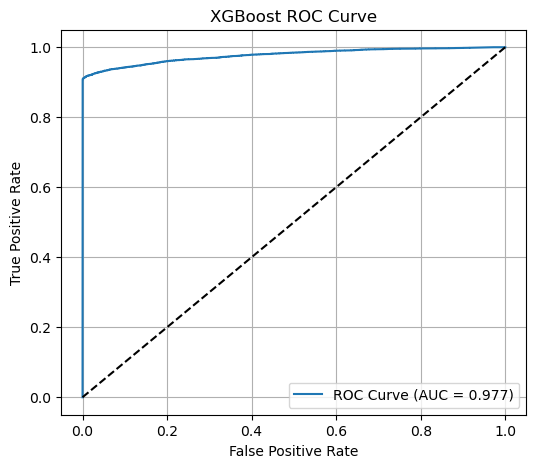

In [31]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend()
plt.grid()
plt.show()


LightGBM

In [32]:
import lightgbm as lgb
import sklearn

print("LightGBM version:", lgb.__version__)
print("Scikit-learn version:", sklearn.__version__)

LightGBM version: 4.6.0
Scikit-learn version: 1.4.2


In [33]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    objective='binary',
    boosting_type='gbdt',
    n_estimators=200,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)


In [34]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'num_leaves': [31, 63],
    'max_depth': [-1, 5, 10],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)


In [35]:
grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05,
                                      n_estimators=200, objective='binary',
                                      random_state=42, subsample=0.8),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [-1, 5, 10],
                         'n_estimators': [100, 200], 'num_leaves': [31, 63]},
             scoring='roc_auc', verbose=1)

In [36]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)

best_lgbmmodel = grid_search.best_estimator_

from sklearn.metrics import accuracy_score, roc_auc_score

y_pred = best_lgbmmodel.predict(X_test)
y_prob = best_lgbmmodel.predict_proba(X_test)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob))

Best Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'num_leaves': 31}
Best CV ROC-AUC: 0.9766819365697212
Test Accuracy: 0.9541994581344343
Test ROC-AUC: 0.9774786864163473


In [37]:
# Predictions
y_pred_lgb = best_lgbmmodel.predict(X_test)

# Classification Report
print("📊 LightGBM Classification Report:\n")
print(classification_report(y_test, y_pred_lgb))


📊 LightGBM Classification Report:

              precision    recall  f1-score   support

         0.0       0.92      1.00      0.96      7751
         1.0       1.00      0.91      0.95      7751

    accuracy                           0.95     15502
   macro avg       0.96      0.95      0.95     15502
weighted avg       0.96      0.95      0.95     15502



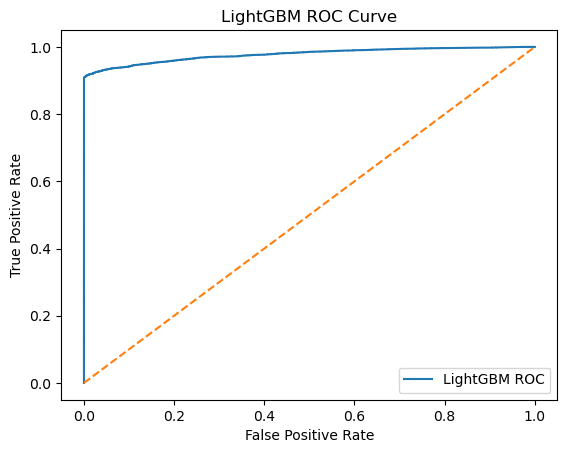

In [38]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label='LightGBM ROC')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LightGBM ROC Curve")
plt.legend()
plt.show()


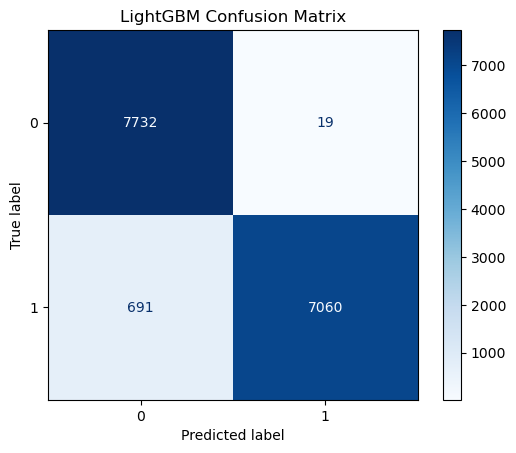

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict
y_pred_lgb = best_lgbmmodel.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lgb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("LightGBM Confusion Matrix")
plt.show()


In [40]:
df.columns

Index(['target', 'mean_consumption', 'std_consumption', 'cv',
       'sudden_drop_count', 'min_consumption', 'num_below_mean', 'skewness',
       'iqr', 'max_drop_pct'],
      dtype='object')

In [41]:
import pickle

# Save LightGBM model
with open("lightgbm_model.pkl", "wb") as f:
    pickle.dump(best_lgbmmodel, f)

# Save XGBoost model
with open("xgboost_model.pkl", "wb") as f:
    pickle.dump(best_xgbmodel, f)
